
MISSING VALUES:
Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


STATISTICS:
              Year  Life expectancy  Adult Mortality  infant deaths  \
count  2938.000000      292

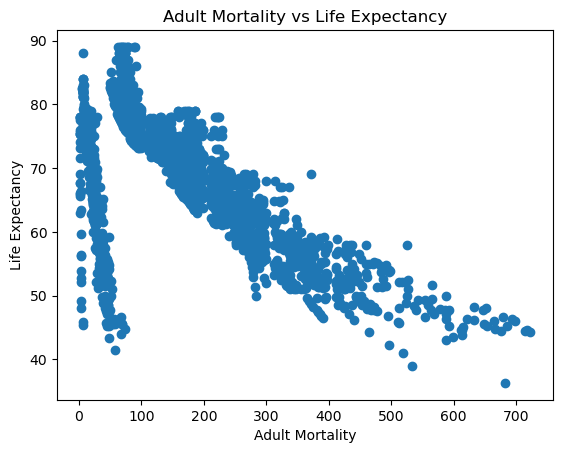

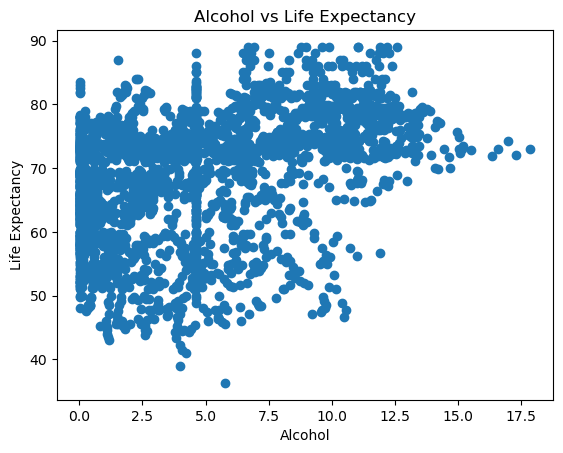

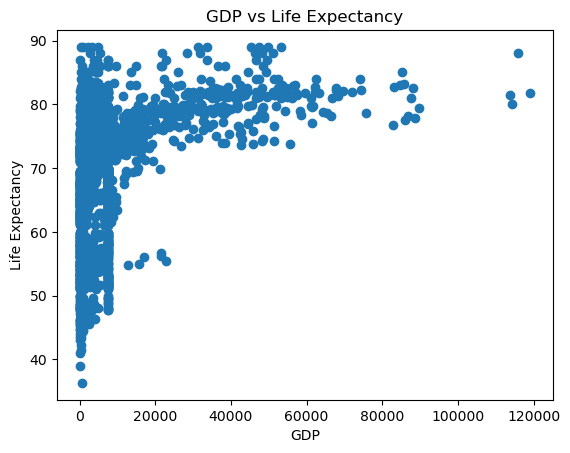

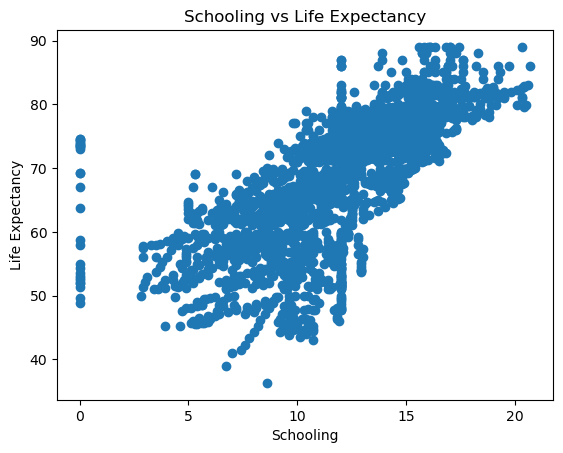

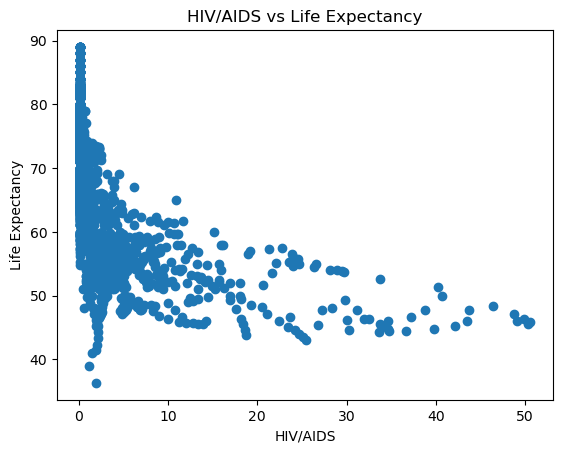

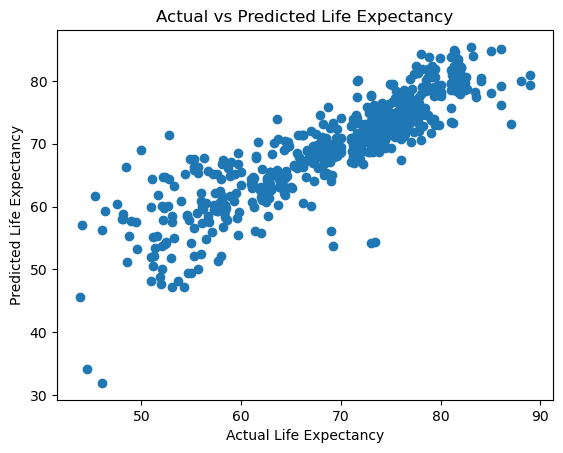

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Life Expectancy Data.csv")
df.columns = df.columns.str.strip() #to remove unnecessary spaces
features = ['Adult Mortality', 'Alcohol', 'GDP', 'Schooling', 'HIV/AIDS']
target = 'Life expectancy'

X = df[features] #input variables
y = df[target] #output we predict

print("\nMISSING VALUES:")
print(df.isnull().sum()) #displays how many missing values are present

print("\n\nSTATISTICS:")
print(df.describe()) #displays basic stats like mean, min/max, std. deviation.
df = df.fillna(df.mean(numeric_only=True)) #fills missing values with it's average

features = ['Adult Mortality', 'Alcohol', 'GDP', 'Schooling', 'HIV/AIDS']
target = 'Life expectancy'
#Re-defining coz datasets are altered
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n\nEVALUATION:")
print("MSE: ",mean_squared_error(y_test, y_pred)) #measures error
print("R^2 Score: ",r2_score(y_test, y_pred)) #provides accuracy

#Shows impact of each feature
coeff_df = pd.DataFrame(model.coef_, features, columns=['Coefficient'])
print("\n\nFEATURE IMPORTANCES(Coefficients):")
print(coeff_df) #-ve[decreases life expectancy], +ve[increases life expectancy]

#for each feature it plots graph against life expectancy
for feature in features:
    plt.figure()
    plt.scatter(df[feature], df[target])
    plt.xlabel(feature)
    plt.ylabel("Life Expectancy")
    plt.title(f"{feature} vs Life Expectancy")
    plt.show()
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()
